# PyTorch

Last week, we built a simple neural model, the perceptron, entirely from scratch using NumPy. This week, we’re shifting gears to focus on **PyTorch**, a deep learning library that:

- Makes it easier to build and train larger neural networks
- Can run models on GPUs for faster training
- Handles some of the complex math behind training

We’ll start by learning about the **tensor**, the basic building block of data in PyTorch. From there, we’ll use those tensors to build and train a multi layer neural network. By the end of this week, you’ll have your first working MLP trained with PyTorch.

## Tensors

Before we can build models in PyTorch, we need to understand the fundamental data structure, the **tensor**. A tensor is just a fancy word for a **multi dimensional array**, like a NumPy array, but with added features that make it useful for building and training deep learning models.

Let’s compare NumPy and PyTorch side by side:

In [1]:
import torch
import numpy as np

np_array = np.array([1.0, 2.0, 3.0])
torch_tensor = torch.tensor([1.0, 2.0, 3.0])

print("NumPy:", np_array)
print("Torch:", torch_tensor)

print("Shape:", torch_tensor.shape)
print("Add 1:", torch_tensor + 1)
print("Mean:", torch.mean(torch_tensor))

NumPy: [1. 2. 3.]
Torch: tensor([1., 2., 3.])
Shape: torch.Size([3])
Add 1: tensor([2., 3., 4.])
Mean: tensor(2.)


### Working with Tensors

Once we create a tensor, we can access its elements using familiar indexing, just like with NumPy arrays. We can:

- Access individual samples and features
- Move data between **NumPy** and **PyTorch** seamlessly

This is helpful when preparing data or integrating with libraries that expect NumPy or Tensor input.

In [ ]:
X = torch.randn(4, 3)
print(X)

print("First sample:", X[0])
print("First feature of second sample:", X[1, 0])
print("Last two features of all samples:", X[:, -2:])

back_to_np = torch_tensor.numpy()
back_to_torch = torch.from_numpy(np_array)

tensor([[-2.2393,  0.6063, -0.8858],
        [-0.2993,  0.2947,  1.1828],
        [ 0.5582, -1.3393, -0.0865],
        [ 1.0246,  1.8710, -0.4489]])
First sample: tensor([-2.2393,  0.6063, -0.8858])
First feature of second sample: tensor(-0.2993)
Last two features of all samples: tensor([[ 0.6063, -0.8858],
        [ 0.2947,  1.1828],
        [-1.3393, -0.0865],
        [ 1.8710, -0.4489]])


## Rebuilding the Perceptron in PyTorch

Let’s start by recreating our basic perceptron using PyTorch, to do this we are going to need the following PyTorch objects.

### nn.Module

In PyTorch, all models are created by defining a class that inherits from `nn.Module`. Think of `nn.Module` as the **base class** for any kind of model, from a simple perceptron to a giant transformer like ChatGPT. It gives us:

- Utilities to easily move your model to GPU
- A standard structure for defining layers
- Built in tracking for weights

### nn.Linear

The most basic building block is `nn.Linear`, which creates a layer containing the same dot product and bias (z = WX + b) that we did in NumPy. However PyTorch also initializes the weights and bias for us, and also keeps track of them as part of the model. The linear object does not include the activation function, we'll use PyTorch functions for those.

 `nn.Linear(input_dim, output_dim)`
- Take in `input_dim` values  
- Output `output_dim` values

In [ ]:
import torch.nn as nn

class Perceptron(nn.Module):   
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def predict(self, x):
        out = self.linear(x)
        return torch.sigmoid(out)

This example is much simpler than our NumPy example, however you might notice it doesn't have a train function. The reason for this is that PyTorch models do not encapsulate everything in the model like sci-kit models, we'll explore how PyTorch handles this in the next section.

## Multi Layer Perceptron

The perceptron we built earlier was powerful enough to separate linearly separable data, but it was limited to learning straight line boundaries. To go beyond this, we can **stack layers of neurons**, creating an MLP.

### MLP Shape

An MLP is just a series of fully connected layers, a **fully connected** layer means **every neuron in one layer connects to every neuron in the next layer**. If you have 3 input features and 3 neurons in the next layer, that layer has **3 × 3 weights + 3 biases**. Each neuron “sees” all inputs.

- The **first layer** takes the input features
- One or more **hidden layers** made of multiple **neurons**
  - The are called hidden layers because they are not visible in the input or output
- The **output layer** produces the final prediction
  - If we have multiple neurons we can actually predict multiple things

<img src="imgs/img-00.png" alt="Neuron Example" style="width:40%;"/>

This stack of layers allows the network to learn **curved and complex decision boundaries** that a single linear layer could never represent. An MLP is just a bigger perceptron with one or more hidden layers and non linearities. We've defined the shape of the MLP, we also need to define how data flows through the network, we call this the **forward pass**.

### Forward Pass

The **forward pass** (also known as the feedforward process) describes how data flows through the network. In more complicated networks data can travel in fairly odd patterns, in an MLP data simply flows from left to right.

1. The input features represent the input layer
2. All neurons in the next layer activate, each neuron calculates passes on a single value

    - weighted sum plus bias
    - non linear activation function
3. The output of these neurons is passed to the next layer, and the process repeats at step 2 if there are more hidden layers
4. The final layer also performs a weighted sum and may or may not include an activation function depending on the task

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleMLP(nn.Module):
    
    def __init__(self, input_dim, hidden_dim=16, output_dim=1):
        ''' Define the shape of the network
        '''
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        '''Define how data flows through network
        '''
        x = self.hidden(x)
        x = F.relu(x)
        
        x = self.output(x)
        x = torch.sigmoid(x)
        
        return x

### Training

Defining a model gives us the structure of the network, what layers it has, how data flows through them, and how the output is computed. But that alone doesn’t make the model useful. To make it **learn** from data we need to train it by running a training loop multiple times, each full pass through the training data is called an **epoch** and consists of the following four steps.

- Run a **forward pass**, this gets predictions from the model, we've defined this already
  - This also creates a graph of all operations that done
- Calculate the **loss**, a single number that tells us **how wrong the model’s predictions are on average** 
  - This value is added to the end of the computation graph
- Use **backpropagation**, a process that goes backwards through the the computation graph figuring out how to tweak each weight
  - For each weight a gradient is calculated based on the weight and loss, the computation graph is discarded here
- Let the **optimizer** apply those tweaks using the **learning rate**
  - The gradients are suggestions, the optimizer decides how to adjust


<img src="imgs/img-02.png" alt="Neuron Example" style="width:40%;"/>


Using the MLP we dfined earlier, let's create a simple training loop

In [ ]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=200, noise=0.2, random_state=42)
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float().view(-1, 1)

model = SimpleMLP(input_dim=2, hidden_dim=16, output_dim=1)
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

for _ in range(200):
    pred = model(X)             # internally this calls forward()
    loss = loss_fn(pred, y)     # how wrong the model is

    optimizer.zero_grad()       # clear old gradients
    loss.backward()             # calculate new gradients
    optimizer.step()            # update weights

### Model Validation

After training, we typically want to **evaluate the model’s performance** on unseen data. At this point, we’re not updating weights, we're simply running the model to generate predictions. To do this efficiently and correctly in PyTorch, we should disable the computation graph. Disabling this reduces memory usage and speeds up computation.

We do this using `torch.no_grad()`, you'll often wrap your metrics and visualizations inside this block.

#### Binary Classification Treshold

In binary classification tasks, the model’s output is usually a **single number between 0 and 1**, thanks to a **Sigmoid activation** at the final layer. This number represents the predicted probability of 1. To turn these soft probabilities into hard class decisions (0 or 1), we apply a threshold:

- If the output is **greater than 0.5**, predict **class 1**  
- If the output is **less than or equal to 0.5**, predict **class 0**

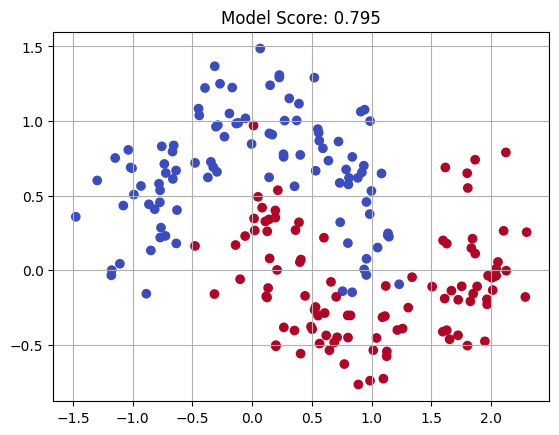

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

with torch.no_grad():
    preds = (model(X) > 0.5).float()
    acc = accuracy_score(y.numpy(), preds.numpy())

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm")
plt.title(label=f"Model Score: {acc}")
plt.grid(True)
plt.show()

# Summary

This week, we transitioned from NumPy to **PyTorch**, a powerful deep learning framework that handles tensor operations, model building, and gpu support.

## PyTorch
- **Tensors**: The core data structure in PyTorch
- **Model Class (`nn.Module`)**: base class for models
- **Linear Layer (`nn.Linear`)**: linear transforms
- **Training Loop**: We implemented the full training process:
  - Forward pass
  - Loss calculation
  - Backpropagation
  - Weight updates